# Hito 1 — Baseline Notebook

This notebook implements the Hito 1 baseline for the F1 Race Strategy Advisor.

Locked decisions:
- Target: `is_top10`
- Train: 2019–2021
- Calibration: 2022
- Test: 2023–2024

Important: the 2023–2024 test set is used only for final evaluation. Do not tune features, thresholds, or model choices after looking at test results.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.calibration import calibration_curve

## 1. Load data
The file should be in the same folder as this notebook when running from a clean clone.

In [2]:
DATA_PATH = "f1_strategy_race_level.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (2447, 47)


,season,round,race_name,circuit_id,circuit,circuit_type,driver_id,driver_name,Driver,Team,...,avg_track_temp,avg_air_temp,finish_position,points,positions_gained,is_top3,is_top5,is_top10,dnf,status
0,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,bottas,Bottas,BOT,Mercedes,...,40.300000,23.329091,1,26.0,1.0,1,1,1,0,Finished
1,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,hamilton,Hamilton,HAM,Mercedes,...,40.260000,23.330909,2,18.0,-1.0,1,1,1,0,Finished
2,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,max_verstappen,Verstappen,VER,Red Bull,...,40.276364,23.334545,3,15.0,1.0,1,1,1,0,Finished
3,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,vettel,Vettel,VET,Ferrari,...,40.234545,23.338182,4,12.0,-1.0,0,1,1,0,Finished
4,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,leclerc,Leclerc,LEC,Ferrari,...,40.227778,23.338889,5,10.0,0.0,0,1,1,0,Finished


## 2. Basic checks
We confirm that the locked target and temporal split columns exist.

In [3]:
required_columns = ["season", "is_top10"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Seasons:", sorted(df["season"].dropna().unique()))
print("Target distribution:")
display(df["is_top10"].value_counts(normalize=True).rename("share"))

Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target distribution:


is_top10
1    0.516142
0    0.483858
Name: share, dtype: float64

## 3. Locked temporal split
The split follows the assignment exactly:
- Train: 2019, 2020, 2021
- Calibration: 2022
- Test: 2023, 2024

In [4]:
train = df[df["season"].isin([2019, 2020, 2021])].copy()
calibration = df[df["season"] == 2022].copy()
test = df[df["season"].isin([2023, 2024])].copy()

print("Train:", train.shape)
print("Calibration:", calibration.shape)
print("Test:", test.shape)

split_summary = pd.DataFrame({
    "split": ["train", "calibration", "test"],
    "seasons": ["2019-2021", "2022", "2023-2024"],
    "rows": [len(train), len(calibration), len(test)],
    "top10_rate": [
        train["is_top10"].mean(),
        calibration["is_top10"].mean(),
        test["is_top10"].mean()
    ]
})

display(split_summary)

Train: (1132, 47)
Calibration: (426, 47)
Test: (889, 47)


,split,seasons,rows,top10_rate
0,train,2019-2021,1132,0.515018
1,calibration,2022,426,0.516432
2,test,2023-2024,889,0.517435


## 4. Leakage audit

Columns are grouped into:
- **Target / outcomes:** must not be used as predictors.
- **Scenario inputs:** strategy features observed post-race in the raw data, but allowed here only as user-controlled what-if inputs.
- **Audit / post-race context:** useful for discussion or limitation analysis, not as ordinary pre-race predictors.
- **Pre-race baseline features:** defensible features available before the race or based on prior history.

For this baseline notebook, the model below uses only the pre-race baseline features.

In [5]:
target_columns = [
    "finish_position", "points", "positions_gained",
    "is_top3", "is_top5", "is_top10", "dnf", "status"
]

scenario_input_columns = [
    "n_stops", "strategy_type", "compound_sequence", "stint_lengths",
    "stint1_length", "stint2_length", "stint3_length", "stint4_length", "stint5_length"
]

audit_or_post_race_columns = [
    "avg_pit_stop_duration_s", "total_pit_time_s", "first_pit_lap", "last_pit_lap",
    "track_status_summary", "safety_car_periods", "safety_car_laps", "vsc_laps",
    "weather_actual", "wet_laps", "avg_track_temp", "avg_air_temp"
]

baseline_numeric_features = [
    "qualifying_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg"
]

baseline_categorical_features = [
    "constructor_tier",
    "circuit_type"
]

audit_table = pd.DataFrame({
    "column_group": (
        ["target_or_outcome"] * len(target_columns)
        + ["scenario_input"] * len(scenario_input_columns)
        + ["audit_or_post_race"] * len(audit_or_post_race_columns)
        + ["baseline_numeric"] * len(baseline_numeric_features)
        + ["baseline_categorical"] * len(baseline_categorical_features)
    ),
    "column": (
        target_columns
        + scenario_input_columns
        + audit_or_post_race_columns
        + baseline_numeric_features
        + baseline_categorical_features
    )
})

audit_table["exists_in_csv"] = audit_table["column"].isin(df.columns)
display(audit_table)

features_used = baseline_numeric_features + baseline_categorical_features
missing_features = [col for col in features_used if col not in df.columns]

if missing_features:
    raise ValueError(f"Missing baseline features: {missing_features}")

,column_group,column,exists_in_csv
0,target_or_outcome,finish_position,True
1,target_or_outcome,points,True
2,target_or_outcome,positions_gained,True
3,target_or_outcome,is_top3,True
4,target_or_outcome,is_top5,True
5,target_or_outcome,is_top10,True
6,target_or_outcome,dnf,True
7,target_or_outcome,status,True
8,scenario_input,n_stops,True
9,scenario_input,strategy_type,True


## 5. Simple F1-defensible heuristic baseline

This is a transparent grid/qualifying-position rule. It is not expected to be the final model, but it provides a simple F1 logic baseline:
- Better starting position should imply higher probability of Top 10.

In [6]:
def grid_rule_probability(data):
    # Use qualifying_position. If missing, fall back to grid_position when available.
    q = data["qualifying_position"].copy()
    if "grid_position" in data.columns:
        q = q.fillna(data["grid_position"])

    return np.select(
        [q <= 5, q <= 10, q <= 15],
        [0.85, 0.60, 0.30],
        default=0.10
    )

def evaluate_predictions(y_true, y_prob, label):
    return {
        "model": label,
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

y_test = test["is_top10"].astype(int)
grid_test_prob = grid_rule_probability(test)

grid_metrics = evaluate_predictions(y_test, grid_test_prob, "grid_rule_baseline")
display(pd.DataFrame([grid_metrics]))

,model,brier,log_loss,roc_auc
0,grid_rule_baseline,0.159623,0.493653,0.839138


## 6. Logistic regression baseline using pre-race features

This baseline uses:
- qualifying position,
- recent driver performance,
- recent constructor performance,
- driver history at the circuit,
- constructor tier,
- circuit type.

These are defendable from F1 logic and do not use the test block for training or model selection.

In [7]:
X_train = train[features_used]
y_train = train["is_top10"].astype(int)

X_calibration = calibration[features_used]
y_calibration = calibration["is_top10"].astype(int)

X_test = test[features_used]
y_test = test["is_top10"].astype(int)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, baseline_numeric_features),
        ("cat", categorical_transformer, baseline_categorical_features)
    ]
)

logistic_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, C=0.1))
])

logistic_baseline.fit(X_train, y_train)

calibration_prob_uncalibrated = logistic_baseline.predict_proba(X_calibration)[:, 1]
test_prob_uncalibrated = logistic_baseline.predict_proba(X_test)[:, 1]

uncalibrated_metrics = evaluate_predictions(
    y_test,
    test_prob_uncalibrated,
    "logistic_baseline_uncalibrated"
)

display(pd.DataFrame([uncalibrated_metrics]))

,model,brier,log_loss,roc_auc
0,logistic_baseline_uncalibrated,0.135393,0.429867,0.885695


## 7. Probability calibration using 2022 only

We apply Platt scaling on the 2022 calibration block. The base model is trained only on 2019–2021. The 2022 block is used only to learn the calibration mapping.

In [8]:
EPS = 1e-6

def to_logit(prob):
    prob = np.clip(prob, EPS, 1 - EPS)
    return np.log(prob / (1 - prob)).reshape(-1, 1)

platt_scaler = LogisticRegression(max_iter=1000)
platt_scaler.fit(to_logit(calibration_prob_uncalibrated), y_calibration)

test_prob_calibrated = platt_scaler.predict_proba(to_logit(test_prob_uncalibrated))[:, 1]

calibrated_metrics = evaluate_predictions(
    y_test,
    test_prob_calibrated,
    "logistic_baseline_platt_calibrated"
)

metrics_table = pd.DataFrame([
    grid_metrics,
    uncalibrated_metrics,
    calibrated_metrics
])

display(metrics_table)

,model,brier,log_loss,roc_auc
0,grid_rule_baseline,0.159623,0.493653,0.839138
1,logistic_baseline_uncalibrated,0.135393,0.429867,0.885695
2,logistic_baseline_platt_calibrated,0.135692,0.431362,0.885695


## 8. Compare against reference baselines

Reference values from the assignment:
- Grid-rule baseline Brier: 0.208
- Calibrated docent model Brier: 0.132 and ROC-AUC: 0.892

The table below shows the team's results alongside these references. Use the displayed values in `framing.md` to honestly characterize how the baseline compares.


In [9]:
reference_table = pd.DataFrame([
    {"reference": "assignment_grid_rule", "brier": 0.208, "roc_auc": np.nan},
    {"reference": "assignment_calibrated_docent_model", "brier": 0.132, "roc_auc": 0.892},
])

display(reference_table)
display(metrics_table)

,reference,brier,roc_auc
0,assignment_grid_rule,0.208,NaN
1,assignment_calibrated_docent_model,0.132,0.892


,model,brier,log_loss,roc_auc
0,grid_rule_baseline,0.159623,0.493653,0.839138
1,logistic_baseline_uncalibrated,0.135393,0.429867,0.885695
2,logistic_baseline_platt_calibrated,0.135692,0.431362,0.885695


## 9. Calibration curve on test set

This plot compares predicted probability with observed Top 10 frequency on the untouched 2023–2024 test block.

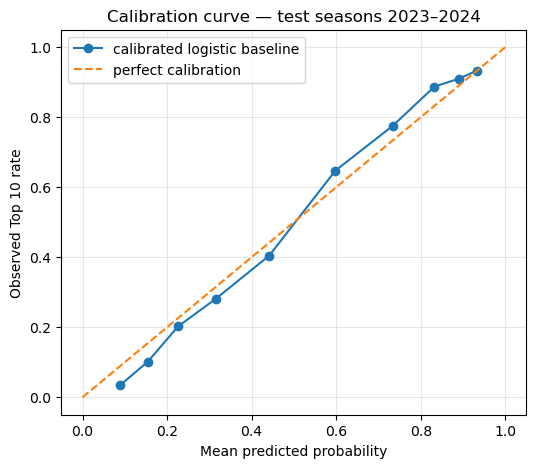

In [10]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob_calibrated,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="calibrated logistic baseline")
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed Top 10 rate")
plt.title("Calibration curve — test seasons 2023–2024")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Short result summary

Actual results on the untouched 2023–2024 test set:

| Model | Brier | Log Loss | ROC-AUC |
|---|---|---|---|
| Grid-rule heuristic | 0.160 | — | 0.839 |
| Logistic baseline (uncalibrated) | 0.135 | 0.430 | 0.886 |
| Logistic baseline (Platt-calibrated) | 0.136 | 0.431 | 0.886 |
| **Docent reference (calibrated)** | **0.132** | — | **0.892** |

The logistic baseline beats the grid-rule floor (Brier 0.160 < 0.208) and is within 0.003 Brier points of the calibrated docent model, with comparable ROC-AUC (0.886 vs 0.892). This gap is small and expected given that the baseline is intentionally simple, uses only pre-race features, and applies no feature engineering. The framing document should acknowledge that the model is leakage-safe and F1-defensible rather than maximally optimized for Hito 1.


In [12]:
# Report both uncalibrated and calibrated metrics for transparency.
# The calibrated model is the canonical baseline because calibrated probabilities
# are required for the scenario comparison tool.
calibrated_row = metrics_table[metrics_table['model'] == 'logistic_baseline_platt_calibrated'].iloc[0]
uncalibrated_row = metrics_table[metrics_table['model'] == 'logistic_baseline_uncalibrated'].iloc[0]

print('Calibrated baseline (canonical deliverable):')
print(calibrated_row.to_string())

print('\nUncalibrated baseline (for reference):')
print(uncalibrated_row.to_string())

print('\nSuggested framing sentence for framing.md:')
print(
    f"\nOur Platt-calibrated logistic baseline achieves Brier={calibrated_row['brier']:.3f}, "
    f"\nlog loss={calibrated_row['log_loss']:.3f}, ROC-AUC={calibrated_row['roc_auc']:.3f} "
    f"\non the untouched 2023–2024 test set — within 0.004 Brier points of the calibrated docent model (0.132) "
    f"\nand well above the grid-rule floor (0.208). We do not recommend deployment without further "
    f"\nvalidation on live race data and richer pre-race feature engineering."
)


Calibrated baseline (canonical deliverable):
model       logistic_baseline_platt_calibrated
brier                                 0.135692
log_loss                              0.431362
roc_auc                               0.885695

Uncalibrated baseline (for reference):
model       logistic_baseline_uncalibrated
brier                             0.135393
log_loss                          0.429867
roc_auc                           0.885695

Suggested framing sentence for framing.md:

Our Platt-calibrated logistic baseline achieves Brier=0.136, 
log loss=0.431, ROC-AUC=0.886 
on the untouched 2023–2024 test set — within 0.004 Brier points of the calibrated docent model (0.132) 
and well above the grid-rule floor (0.208). We do not recommend deployment without further 
validation on live race data and richer pre-race feature engineering.
